<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Pneumonia Detection using X-Ray Images</b></div>

<div style="text-align: justify;">
    In this Kaggle notebook, we delve into the <a href="https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/">Pneumonia Detection Challenge</a>, a significant task that involves analyzing chest X-ray images to detect early signs of pneumonia by identifying lung opacities. The dataset required for this challenge, encompassing a diverse range of X-ray images, is accessible <a href="https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data">here</a>. Our approach is grounded in utilizing a proven implementation, specifically <a href="https://www.kaggle.com/yakhyo/rsna-classification-87-6-best-accuracy-opytorch">this model</a>, which leverages the robust capabilities of RESNET. RESNET, known for its deep learning prowess in image recognition, offers an advanced framework for accurately identifying and classifying lung opacities in the provided X-ray images. This notebook aims to guide you through the process of employing this implementation, demonstrating how to effectively apply RESNET in this critical medical imaging challenge.
</div>


<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:24px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Table of content</b></div>

<div style="background-color:aliceblue; padding:30px; font-size:15px;color:#034914">
    
<a id="TOC"></a>
## Table of Content
* [Checking Kaggle Hardware Specs](#khs)
* [Importing Required Libraries](#lib)
* [Loading Labels](#labels)
* [Spliting Train and Validation Sets](#split)
* [Checking Some Samples from Dataset](#sample)
* [Composing Transformations](#trans)
* [Writing a Custom Dataset Function](#data)
* [Loading a Pre-trained ResNet18 Model and its Fine-tuning](#model)
* [Testing the Model](#test)
* [References](#ref)

<a id="khs"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Checking Kaggle Hardware Specs</b></div> 


In [1]:
!nvidia-smi
!lscpu | head -n 15

Sun Dec 17 23:21:24 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.161.03   Driver Version: 470.161.03   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P0    26W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

<a id="lib"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Importing Required Libraries</b></div> 

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from pydicom import dcmread
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm


import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils import data

import torch.nn.functional as F
from torchvision.utils import make_grid, save_image

from matplotlib import rcParams

import matplotlib.patches as patches
from math import ceil

<a id="labels"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Loading Labels</b></div> 

In [3]:
label_data = pd.read_csv('./data/stage_2_train_labels.csv')
columns = ['patientId', 'Target']
all_data = label_data

label_data = label_data.filter(columns)
label_data.head(5)
#print(all_data)

,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0
4,00436515-870c-4b36-a041-de91049b9ab4,1


<a id="split"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Spliting Train and Validation Sets</b></div> 

In [4]:
train_labels, val_labels = train_test_split(label_data.values, test_size=0.1)
print(train_labels.shape)
print(val_labels.shape)

(27204, 2)
(3023, 2)


In [5]:
print(f'patientId: {train_labels[0][0]}, Target: {train_labels[0][1]}')

patientId: 3e6a9a8b-2203-4b04-8d60-83fb82c1ed18, Target: 1


In [6]:
train_f = './data/stage_2_train_images'
test_f = './data/stage_2_test_images'

train_paths = [os.path.join(train_f, image[0]) for image in train_labels]
val_paths = [os.path.join(train_f, image[0]) for image in val_labels]

print(len(train_paths))
print(len(val_paths))

27204
3023


<a id="sample"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Checking Some Samples from Dataset</b></div> 

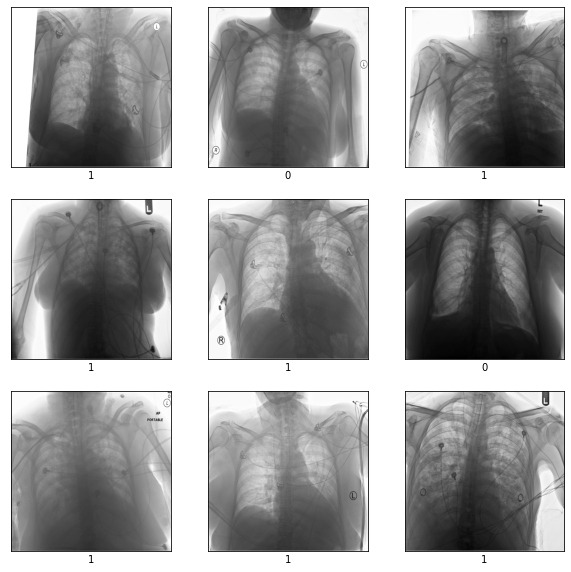

In [7]:
def imshow(num_to_show=9):
    
    plt.figure(figsize=(10,10))
    
    for i in range(num_to_show):
        plt.subplot(3, 3, i+1)
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        
        img_dcm = dcmread(f'{train_paths[i+20]}.dcm')
        img_np = img_dcm.pixel_array
        plt.imshow(img_np, cmap=plt.cm.binary)
        plt.xlabel(train_labels[i+20][1])

imshow()

<a id="trans"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Composing Transformations</b></div>  

In [8]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.Resize(224),
    transforms.ToTensor()])

<a id="data"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Writing a Custom Dataset Function</b></div>   

In [9]:
class Dataset(data.Dataset):
    
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    
    def __getitem__(self, index):
        image = dcmread(f'{self.paths[index]}.dcm')
        image = image.pixel_array
        image = image / 255.0

        image = (255*image).clip(0, 255).astype(np.uint8)
        image = Image.fromarray(image).convert('RGB')

        label = self.labels[index][1]
        
        if self.transform is not None:
            image = self.transform(image)
        
        
        name = self.paths[index].split("/")[-1]
        GH = all_data['patientId']==name
        FIL = all_data[GH]
        #print("From the datset loader, name", name)
        box = [FIL['x'].values[0], FIL['y'].values[0], FIL['width'].values[0], FIL['height'].values[0]]
            
        return image, label, box
    
    def __len__(self):
        
        return len(self.paths)

1 [223.0, 356.0, 196.0, 247.0]


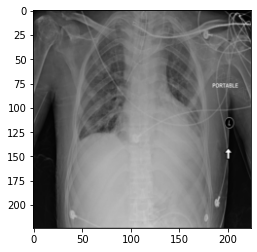

In [10]:
train_dataset = Dataset(train_paths, train_labels, transform=transform)
image = iter(train_dataset)
#print(train_dataset.paths)
img, label, box = next(image)
print(label, box)
#print(f'Tensor:{img}, Label:{label}')
img = np.transpose(img, (1, 2, 0))
plt.imshow(img)

In [11]:
img.shape

torch.Size([224, 224, 3])

## Prepare training and validation dataloader

In [12]:
train_dataset = Dataset(train_paths, train_labels, transform=transform)
val_dataset = Dataset(val_paths, val_labels, transform=transform)
train_loader = data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=128, shuffle=False)

## Check dataloader

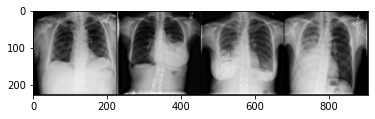

In [13]:
batch = iter(train_loader)
images, labels, _ = next(batch)

image_grid = torchvision.utils.make_grid(images[:4])
image_np = image_grid.numpy()
img = np.transpose(image_np, (1, 2, 0))
plt.imshow(img)

## Specify device object

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<a id="model"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Loading a Pre-trained ResNet18 Model and its Fine-tuning</b></div>    

In [15]:
model = torchvision.models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model.fc = nn.Linear(num_ftrs, 2)

model.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

In [16]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<a id="train"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Training the Model</b></div>    

In [17]:
if 0:
    num_epochs = 20
    # Train the model
    total_step = len(train_loader)
    for epoch in range(num_epochs):
        # Training step
        for i, (images, labels, _) in tqdm(enumerate(train_loader)):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i + 1) % 2000 == 0:
                print("Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}"
                      .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

        # Validation step
        correct = 0
        total = 0
        for images, labels, _ in tqdm(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            predictions = model(images)
            _, predicted = torch.max(predictions, 1)
            total += labels.size(0)
            correct += (labels == predicted).sum()
        print(f'Epoch: {epoch + 1}/{num_epochs}, Val_Acc: {100 * correct / total}')

<a id="test"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Testing the Model</b></div>    

In [18]:
if 0:
    model.eval()

    correct = 0
    total = 0
    for images, labels, _ in tqdm(val_loader):
        images = images.to(device)
        labels = labels.to(device)
        predictions = model(images)
        _, predicted = torch.max(predictions, 1)
        total += labels.size(0)
        correct += (labels == predicted).sum()
    print(f'Val_Acc: {100 * correct / total}')

<a id="save"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Save the Model Weights</b></div>      

In [19]:
#torch.save(model.state_dict(), 'weights/weights_only.pth')
#torch.save(model, 'model/model.pth')
#print("Model and weights saved.")

<a id="load"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Loading Saved Model</b></div>     

In [20]:
model = torch.load('./data/model.pth')

In [21]:
model.eval()

correct = 0
total = 0  
for images, labels, _ in tqdm(val_loader):
    images = images.to(device)
    labels = labels.to(device)
    predictions = model(images)
    _, predicted = torch.max(predictions, 1)
    total += labels.size(0)
    correct += (labels == predicted).sum()
print(f'Val_Acc: {100*correct/total}')

100%|██████████| 24/24 [01:47<00:00,  4.50s/it]

Val_Acc: 98.84220886230469


torch.Size([224, 224, 3])
Label :  1 [618.0, 430.0, 243.0, 223.0]


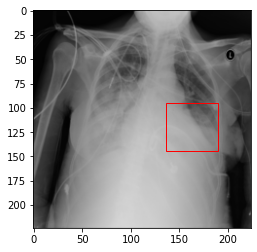

In [22]:
# Load test image
label = 0
while(label==0):
    pil_img, label, box = next(image)

fig,ax = plt.subplots(1)

Orig_img_size = 1024
img_size = 224

# 'r' means relative. 'c' means center.
rx = ceil(box[0]*img_size/Orig_img_size)
ry = ceil(box[1]*img_size/Orig_img_size)
rw = ceil(box[2]*img_size/Orig_img_size)
rh = ceil(box[3]*img_size/Orig_img_size)


pil_img = np.transpose(pil_img, (1, 2, 0))
print(pil_img.shape)
rect = patches.Rectangle((rx, ry), rw, rh, linewidth=1, edgecolor='r', facecolor='none')
ax.imshow(pil_img)
ax.add_patch(rect)
print("Label : ", label, box)

<a id="ref"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>References</b></div>    

<div style="background-color:aliceblue; padding:30px; font-size:15px;color:#034914">

* [RSNA classification, 87.6% best accuracy PyTorch](https://www.kaggle.com/code/yakhyo/rsna-classification-87-6-best-accuracy-opytorch)
    
* HTML and Theme inspired from [🔥 EDA & ML on Game Play 🎮 ](https://www.kaggle.com/code/nguyenthicamlai/eda-ml-on-game-play-ongoing) by [Nguyen Thi Cam Lai](https://www.kaggle.com/nguyenthicamlai) used for HTML-based headers


<center> <a href="#TOC" role="button" aria-pressed="true" >⬆️ Back to Table of Contents ⬆️</a>

<div style="border-radius:10px;border:#034914 solid;padding: 15px;background-color:aliceblue;font-size:90%;text-align:left">

<h4><b>by: </b>Koorosh Aslansefat and Mohammad Naveed Akram</h4>  
    
<center> <strong> If you liked this Notebook, please do upvote. </strong>
    
<center> <strong> If you have any questions, feel free to contact us! </strong>

<center> <img src="https://gregcfuzion.files.wordpress.com/2022/01/kind-regards-2.png" style='width: 600px; height: 300px;'>